# Diagrama de arquitectura del modelo convolucional 1D v2 (U-Net residual)

Figura de la arquitectura del modelo entrenado en `cnn-v2_training.ipynb`, para la memoria. Es un **esquema por etapas**: una caja por nivel de la U-Net, no por capa. El modelo tiene 95 capas, y cualquier figura que dibuje una caja por capa sale como una tira de unos 15000 px de ancho —132:1— que no cabe en una página: reducida a una columna, cada capa mide una decena de píxeles y no se lee nada.

El esquema se escribe en Graphviz, que ya entra con `pydot`. La estructura es la de `cnn-v2_training.ipynb`, así que hay que repasarla si cambia la red.

In [1]:
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

MODELS_DIR = SOLUTION_DIR / "models"
CNN_DIR = MODELS_DIR / "cnn"

# Modelo a dibujar y figura que genera este cuaderno
MODEL_PATH = CNN_DIR / "cnn-v2.keras"
DIAGRAM_PATH = CNN_DIR / "cnn-v2_architectural-diagram.png"

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


El `.keras` guarda la arquitectura junto con los pesos. El resumen no genera la figura —el esquema está escrito a mano—, pero sirve para comprobar contra el modelo entrenado las formas y el número de filtros que rotula el diagrama.

In [2]:
import tensorflow as tf

model_cnn_v2 = tf.keras.models.load_model(MODEL_PATH)

model_cnn_v2.summary()

2026-08-30 22:53:25.657253: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-30 22:53:25.795458: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-30 22:53:28.451212: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2026-08-30 22:53:29.945515: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cnn_unet_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interp_flux         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interp_err          │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2666, 2)   │          0 │ interp_flux[0][0… │
│ (Concatenate)       │                   │            │ interp_err[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d      │ (None, 2672, 2)   │          0 │ concatenate[0][0] │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2672, 64)  │      1,216 │ zero_padding1d[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2672, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2672, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2672, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2672, 64)  │          0 │ multiply[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2672, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1336, 96)  │     30,816 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1336, 96)  │     64,608 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1336, 96)  │     64,608 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ conv1d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12)        │      1,164 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      1,248 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,801,941 (25.95 MB)

 Trainable params: 2,267,313 (8.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,534,628 (17.30 MB)

Cómo se lee el esquema:

- La rama izquierda es el **codificador**: cada nivel es un bloque residual con atención de canal, y entre niveles una convolución de paso 2 que reduce a la mitad la longitud del espectro (2672 → 1336 → 668 → 334 puntos). El número de filtros crece al bajar (64 → 96 → 128 → 160) para compensar la pérdida de resolución.
- Abajo está el **cuello de botella**, dos bloques residuales de 160 filtros que ven el espectro completo a resolución 1/8.
- La rama derecha es el **decodificador**, simétrico: sobremuestreo por 2, concatenación de la conexión de salto del nivel correspondiente y un bloque residual, hasta volver a la malla original.
- Las flechas discontinuas horizontales son las **conexiones de salto**, que devuelven al decodificador el detalle fino que el submuestreo pierde.
- Arriba, la **conexión residual global**: la red aprende la corrección y la suma al flujo interpolado, no genera el espectro desde cero.

El recuadro de la derecha desarrolla lo que hay dentro de una de esas cajas: las dos convoluciones, la atención de canal (*squeeze-and-excitation*), que pondera cada filtro con un factor aprendido, y el atajo que las suma.

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn-v2_architectural-diagram.png
Tamaño: (7133, 335) px


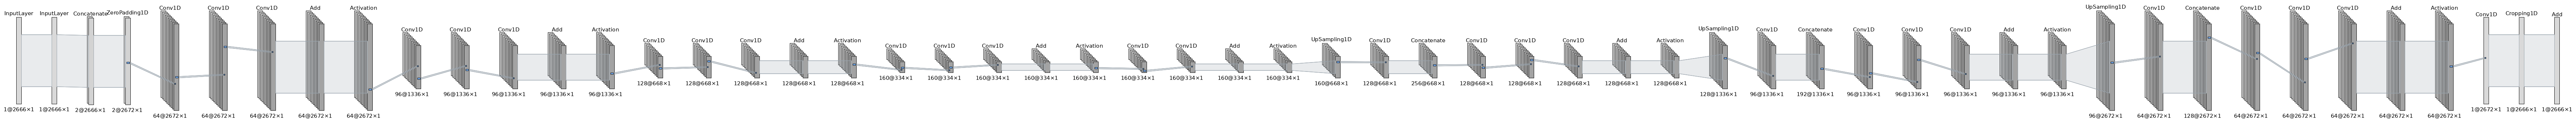

In [3]:
import pydot

from IPython.display import Image

DOT = """digraph unet {
    rankdir=TB
    bgcolor="white"
    splines=polyline
    dpi=150
    nodesep=0.35
    ranksep=0.45
    node [shape=box style="rounded,filled" fillcolor="#eef2f7" color="#5b6b7c"
          fontname="DejaVu Sans" fontsize=11 margin="0.18,0.10"]
    edge [fontname="DejaVu Sans" fontsize=9 color="#5b6b7c"]

    entrada [label="interp_flux + interp_err\n2666 × 2" fillcolor="#dfe7ef"]
    conv0   [label="Conv1D 64 (k9)\n2672"]
    enc1    [label="residual + SE\n64 @ 2672"]
    enc2    [label="residual + SE\n96 @ 1336"]
    enc3    [label="residual + SE\n128 @ 668"]
    cuello  [label="2 × residual + SE\n160 @ 334" fillcolor="#d7e3f0"]
    dec3    [label="residual + SE\n128 @ 668"]
    dec2    [label="residual + SE\n96 @ 1336"]
    dec1    [label="residual + SE\n64 @ 2672"]
    salida  [label="Conv1D 1 (k5) + recorte\n⊕ flujo interpolado\n2666" fillcolor="#dfe7ef"]

    entrada -> conv0
    conv0 -> enc1
    enc1 -> enc2 [label="  Conv1D paso 2"]
    enc2 -> enc3 [label="  Conv1D paso 2"]
    enc3 -> cuello [label="  Conv1D paso 2"]

    // El rango de las cajas lo fijan los grupos 'rank=same' del final, de modo
    // que estas aristas se escriben en el sentido real del flujo, hacia arriba
    cuello -> dec3 [constraint=false label="  ×2 + concat"]
    dec3 -> dec2 [constraint=false label="  ×2 + concat"]
    dec2 -> dec1 [constraint=false label="  ×2 + concat"]
    dec1 -> salida [constraint=false]

    enc1 -> dec1 [constraint=false style=dashed color="#9aa4ad" label="salto"]
    enc2 -> dec2 [constraint=false style=dashed color="#9aa4ad" label="salto"]
    enc3 -> dec3 [constraint=false style=dashed color="#9aa4ad" label="salto"]
    entrada -> salida [constraint=false style=dashed color="#9aa4ad"
                       label="conexión residual global"]

    // Las dos ramas de la U, enfrentadas por niveles
    { rank=same; entrada; salida }
    { rank=same; enc1; dec1 }
    { rank=same; enc2; dec2 }
    { rank=same; enc3; dec3 }

    subgraph cluster_bloque {
        label="bloque residual + SE"
        fontname="DejaVu Sans" fontsize=11 fontcolor="#5b6b7c"
        color="#c3ccd6" style=rounded margin=12

        b_in  [label="x\nf @ L" fillcolor="#dfe7ef"]
        b_c1  [label="Conv1D f (k7) + ELU"]
        b_c2  [label="Conv1D f (k7)"]
        b_se  [label="SE: media global → Dense f/8 (ELU)\n→ Dense f (sigmoide) → escala por canal"]
        b_add [label="⊕" shape=circle width=0.3 fixedsize=true fillcolor="#dfe7ef"]
        b_out [label="ELU\nf @ L" fillcolor="#dfe7ef"]

        b_in -> b_c1 -> b_c2 -> b_se -> b_add -> b_out
        b_in -> b_add [constraint=false style=dashed color="#9aa4ad" label="  atajo"]
    }
}"""

(graph,) = pydot.graph_from_dot_data(DOT)
graph.write_png(str(DIAGRAM_PATH))

print("Diagrama guardado en:", DIAGRAM_PATH)

Image(str(DIAGRAM_PATH))